<a href="https://colab.research.google.com/github/Ymin-2/ESAA/blob/main/ESAA_OB_WEEK09_1_CNN(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **5.2 합성곱 신경망 맛보기** (코드 11개)

fashion_mnis 데이터셋을 사용해 합성곱 신경망 직접 구현

In [ ]:
# 라이브러리 호출
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms # 데이터 전처리를 위해 사용하는 라이브러리
from torch.utils.data import Dataset, DataLoader

In [ ]:
# CPU 혹은 GPU 장치 확인
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
from IPython.testing import test
# fashion_mnist 데이터셋 내려받기
train_dataset = torchvision.datasets.FashionMNIST("../chap05/data", download = True,
                                                  transform = transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST("../chap05/data", download = True,
                                                  transform = transforms.Compose([transforms.ToTensor()]))

1. torchvision.datasets: torch.utils.data.Datset의 하위 클래스 --> 다양한 데이터셋을 포함함.  
torchvision.datsets에서 사용하는 주요 파라미터: torchvision.datasets.FashionMNIST("../chap05/data", download = True,
                                                  transform = transforms.Compose([transforms.ToTensor()]))
- "../chap05/data": FashionMNIST를 내려받을 위치 지정
- download: download:를 True로 변경해주면 첫 번째 파라미터의 위치에 해당 데이터셋이 있는지 확인한 후 내려받기
- transform: 이미지를 텐서(0~1)로 변경하기

In [ ]:
# fashion_mnist 데이터를 데이터로더에 전달
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 100)

torch.utils.data.DataLoader()를 사용해 원하는 크기의 배치 단위로 데이터를 불러오거나, 순서가 무작위로 섞이도록 가능  
데이터로더에서 사용하는 파라미터: torch.utils.data.DataLoader(train_dataset, batch_size = 100)
- train_dataset: 데이터를 불러올 데이터셋 지정
- batch_size: 데이터를 배치로 묶어줌.

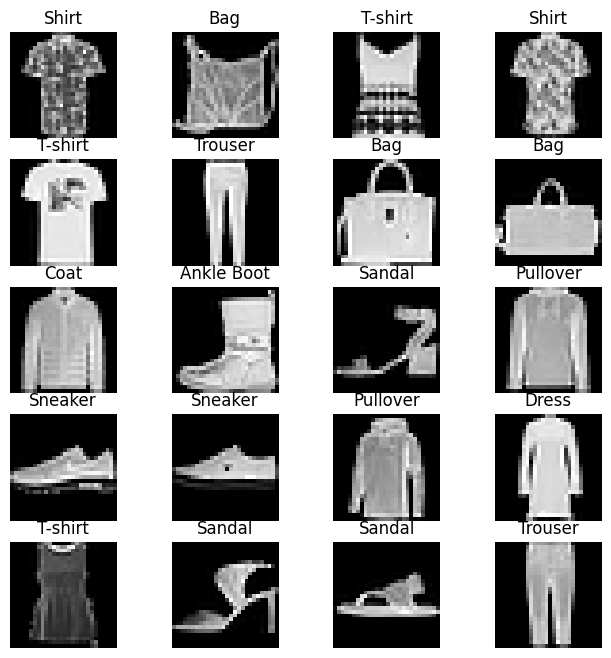

In [ ]:
# 분류에 사용될 클래스 정의
labels_map = {0: 'T-shirt', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
              5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle Boot'} # 열 개의 클래스

fig = plt.figure(figsize=(8, 8)); # 출력할 이미지의 가로세로 길이로 단위는 inch
columns = 4;
rows = 5;
for i in range(1, columns*rows + 1):
  img_xy = np.random.randint(len(train_dataset))
  img = train_dataset[img_xy][0][0,:,:]
  fig.add_subplot(rows, columns, i)
  plt.title(labels_map[train_dataset[img_xy][1]])
  plt.axis('off')
  plt.imshow(img, cmap='gray')
plt.show() # 20개의 이미지 데이터를 시각적으로 표현

- np.random: 무작위로 데이터를 생성할 때 사용
- np.random.randint(): 이산형 분포를 갖는 데이터에서 무작위 표본을 추출할 때 사용
- random.randint(len(train_dataset)): 0~(train_dataset의 길이) 값을 갖는 분포에서 랜덤한 숫자 한 개를 생성

합성곱 신경망과 심층 신경망의 비교 위해 먼저 심층 신경망 생성 후 학습  
즉, ConvNet이 적용되지 않은 네트워크 먼저 만들기

In [ ]:
# 심층 신경망 모델 생성
class FashionDNN(nn.Module):
  def __init__(self): # 1
    super(FashionDNN, self).__init__()
    self.fc1 = nn.Linear(in_features=784, out_features=256) # 2
    self.drop = nn.Dropout(0.25) # 3
    self.fc2 = nn.Linear(in_features = 256, out_features = 128)
    self.fc3 = nn.Linear(in_features = 128, out_features = 10)

  def forward(self, input_data): # 4
    out = input_data.view(-1, 784) # 5
    out = F.relu(self.fc1(out)) # 6
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self.fc3(out)
    return out

1. 클래스 형태의 모델은 항상 torch.nn.Module을 상속받음  
- __init__(): 객체가 갖는 속성 값 초기화하는 역할, 객체가 생성될 때 자동으로 호출됨
2. nn: 딥러닝 모델 구성에 필요한 모듈이 모여 있는 패키지
- Linear: 단순 선형 회귀 모델을 만들 때 사용
3. torch.nn.Dropout(p): p만큼의 비율로 텐서의 값이 0이 됨, 0이 되지 않는 값들은 기존 값에 (1/(1-p))만큼 곱해져 커짐
4. forward(): 모델이 학습 데이터를 입력받아서 순전파 학습을 진행시킴, 반드시 forward라는 이름의 함수여야 함
5. view: 넘파이의 reshape와 같은 역할, 텐서의 shape를 변경해줌
6. 활성화 함수를 지정하는 방법
- F.relu(): forward() 함수에서 정의
- nn.ReLu(): __init__() 함수에서 정의

모델을 학습시키기 전에 손실 함수, 학습률, 옵티마이저 정의

In [ ]:
# 심층 신경망에서 필요한 파라미터 정의
learning_rate = 0.001;
model = FashionDNN();
model.to(device)

criterion = nn.CrossEntropyLoss(); # 분류 문제에서 사용하는 손실 함수
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate);
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


옵티마이저를 위한 경사 하강법: Adam 사용  
학습률을 의미하는 lr: 0.001 사용

In [ ]:
# 심층 신경망을 이용한 모델 학습
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    train = Variable(images.view(100, 1, 28, 28))
    labels = Variable(labels)

    outputs = model(train) # 학습 데이터를 모델에 적용
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50): # count를 50으로 나누었을 때 나머지가 0이 아니라면 실행
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100, 1, 28, 28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 500):
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.540310800075531, Accuracy: 84.8133316040039%
Iteration: 1000, Loss: 0.4649389386177063, Accuracy: 86.55500030517578%
Iteration: 1500, Loss: 0.35650965571403503, Accuracy: 86.89167022705078%
Iteration: 2000, Loss: 0.32115599513053894, Accuracy: 87.30333709716797%
Iteration: 2500, Loss: 0.2564709186553955, Accuracy: 87.98666381835938%
Iteration: 3000, Loss: 0.2310970276594162, Accuracy: 88.5%


분류 문제에서 클래스가 세 개 이상일 때의 주의사항
- 정확도가 80% 이상이었다고 하자. 하지만 80%라는 값이 모든 클래스가 동등하게 고려된 것인지, 특정 클래스의 분류가 높았던 것인지에 대해 알 수 없음에 유의해야 함
- 정확도가 90% 이상이었다고 하자. 하지만 100개의 데이터 중 90개가 하나의 클래스에 속할 경우 90%의 정확도는 높다고 할 수 없다. 즉, 모든 데이터를 특정 클래스에 속한다고 예측해도 90%의 예측 결과가 나오기 때문에 특성에 따라 정확도를 잘 관측해야 함.

In [ ]:
# 합성곱 네트워크 생성
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN, self).__init__()
    self.layer1 = nn.Sequential(
        nn.Conv2d(in_channels = 1, out_channels = 32, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2)
    )
    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.fc1 = nn.Linear(in_features=64*6*6, out_features = 600)
    self.drop = nn.Dropout2d(0.25)
    self.fc2 = nn.Linear(in_features = 600, out_features = 120)
    self.fc3 = nn.Linear(in_features = 120, out_features = 10) # 마지막 계층의 out_features는 클래스 개수를 의미

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = out.view(out.size(0), -1)
    out = self.fc1(out)
    out = self.drop(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

Conv2d 계층에서의 출력 크기 구하는 공식
- 출력 크기 = (W-F+2P)/S+1
  - W: 입력 데이터의 크기
  - F: 커널 크기
  - P: 패딩 크기
  - S: 스트라이드

MaxPool2d 계층에서의 출력 크기 구하는 공식
- 출력 크기 = IF/F
  - IF: 입력 필터의 크기
  - F: 커널의 크기

In [ ]:
# 합성곱 네트워크를 위한 파라미터 정의
learning_rate = 0.001;
model = FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [ ]:
# 모델 학습 및 성능 평가
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    train = Variable(images.view(100, 1, 28, 28))
    labels = Variable(labels)

    outputs = model(train)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not(count % 50):
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100, 1, 28, 28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not(count % 500):
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Iteration: 500, Loss: 0.48476529121398926, Accuracy: 88.36166381835938%
Iteration: 1000, Loss: 0.3489140570163727, Accuracy: 88.67500305175781%
Iteration: 1500, Loss: 0.3529773950576782, Accuracy: 90.55000305175781%
Iteration: 2000, Loss: 0.20175789296627045, Accuracy: 91.3499984741211%
Iteration: 2500, Loss: 0.12015769630670547, Accuracy: 92.51000213623047%
Iteration: 3000, Loss: 0.18054300546646118, Accuracy: 91.66166687011719%
